# Superstore Sales Data Analysis

This project explores the Superstore dataset to understand the factors affecting sales and profitability.

Key questions explored:
- Which regions generate the most sales?
- Which product categories produce the highest profit?
- Which customer segments contribute most revenue?
- How do discounts impact profitability?
- How do sales change over time?

Tools used:
- Python
- Pandas
- Seaborn
- Matplotlib

# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the superstore dataset and displaying the first 10 Rows

In [14]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


# Checking Data Types

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# Checking Data Values

In [20]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

# Fixing Ship Date Data to Datetime

In [51]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Checking Missing Values

In [23]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# Checking Duplicated Rows

In [27]:
df.duplicated().sum()

np.int64(0)

# Checking Unique Values

In [28]:
df['Category'].unique()
df['Region'].unique()
df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

# Check Numeric Columns

In [29]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108


# Checking Outliers

<Axes: xlabel='Sales'>

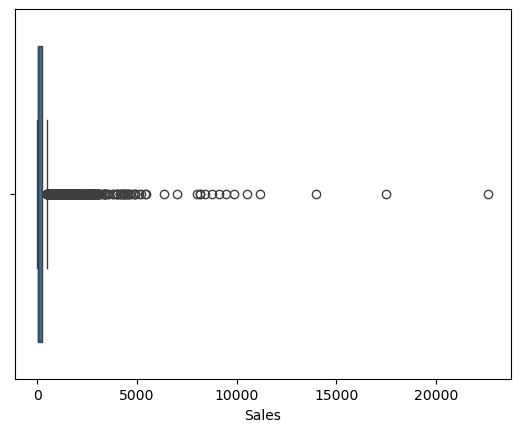

In [30]:
sns.boxplot(x=df['Sales'])

# Checking Time Columns

In [31]:
df['Order Date'].min()
df['Order Date'].max()

Timestamp('2017-12-30 00:00:00')

# Creating Dervied Columns

In [32]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Summary Check

In [33]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    0 non-null      object        
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code      9994
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Year                0
Month               0
dtype: int64

In [34]:
df['Postal Code'].head(10)

0    None
1    None
2    None
3    None
4    None
5    None
6    None
7    None
8    None
9    None
Name: Postal Code, dtype: object

# 1. Sales by Region Group by Sales, Sum Sales

In [35]:
df.groupby('Region')['Sales'].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

# Sales by Region Graph (Region, Sales)

From the chart, the West region clearly brings in the highest sales compared to the other regions. This suggests that the company has a strong customer base or better market presence there. On the other hand, the South region shows the lowest sales, which could mean there is room for growth or that the company may need to strengthen its strategy in that area.

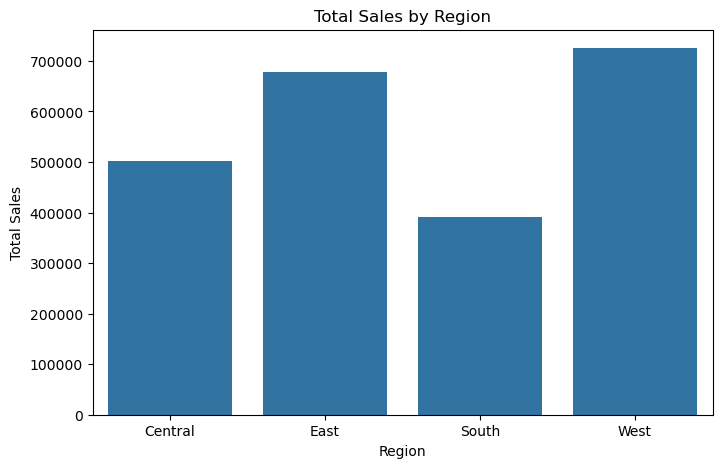

In [36]:
sales_region = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=sales_region.index, y=sales_region.values)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

# 2. Profit by Category

In [37]:
df.groupby('Category')['Profit'].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

# Profit by Category Graph

Looking at the profit across categories, Technology stands out as the most profitable category. This indicates that technology products are likely high-value items with good margins. In comparison, Furniture generates much less profit, which may mean that these products have higher costs or lower margins.

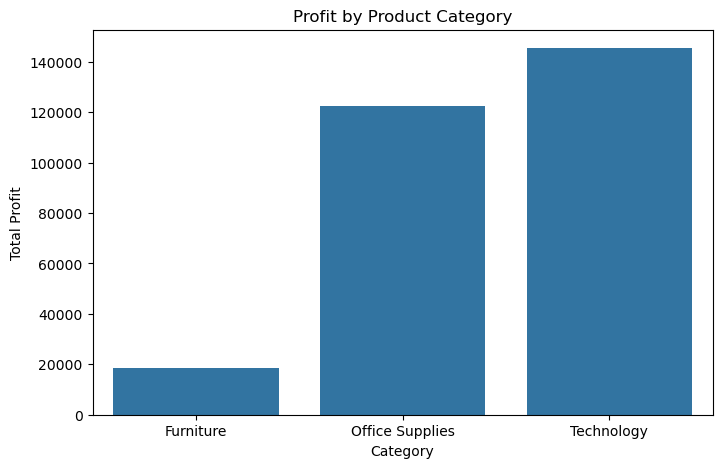

In [38]:
profit_category = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=profit_category.index, y=profit_category.values)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

# 3. Sales by Segment(Group by Segment, Sum Sales)

In [39]:
df.groupby('Segment')['Sales'].sum()

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

# Sales by Customer Segment Graph

The chart shows that the Consumer segment contributes the majority of sales. This means individual customers are the main drivers of revenue for the company. While Corporate and Home Office customers also contribute, their overall sales are noticeably smaller compared to consumer purchases.

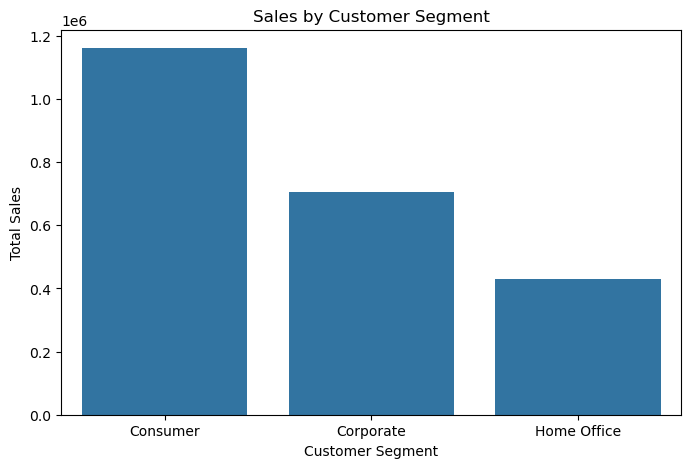

In [40]:
sales_segment = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=sales_segment.index, y=sales_segment.values)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.show()

# 4. Discount Vs Profit

<Axes: xlabel='Discount', ylabel='Profit'>

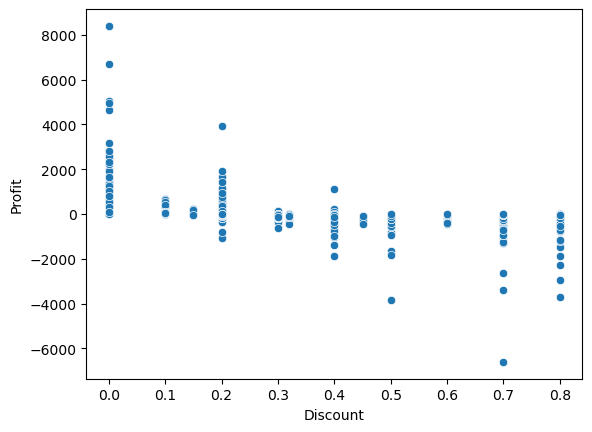

In [42]:
sns.scatterplot(x='Discount', y='Profit',data=df)

# Discount Vs Profit Graph

When comparing discounts with profit, it becomes clear that larger discounts often lead to lower profits. In some cases, high discounts even result in negative profit, meaning the company is losing money on those orders. This suggests that the company should be careful with aggressive discount strategies.

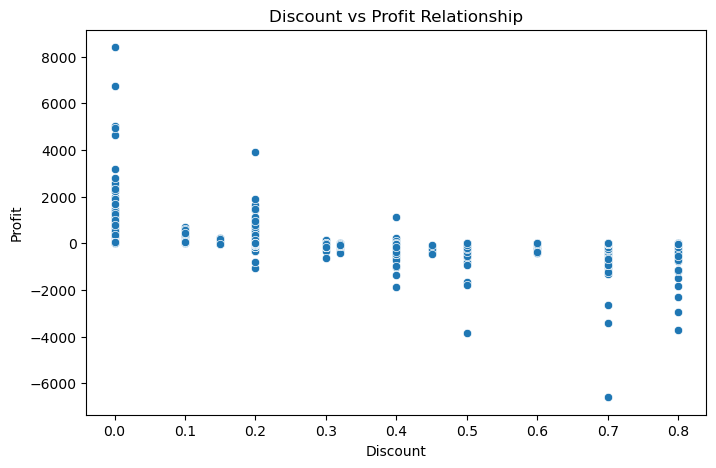

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='Discount', y='Profit')

plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

# 5. Monthly Sales Trend

In [48]:
# Step 1: Convert Data Column

df['Order Date'] = pd.to_datetime(df['Order Date'])

In [49]:
# step 2: Extract Month

df['Month'] = df['Order Date'].dt.month

In [50]:
# step 3: Calculate Sales by Month

df.groupby('Month')['Sales'].sum()

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

# Sales by Month Graph

The monthly sales trend shows that sales fluctuate throughout the year, with some months performing better than others. There is a noticeable increase toward the later months of the year, which could be due to seasonal demand, holiday shopping, or promotional campaigns.

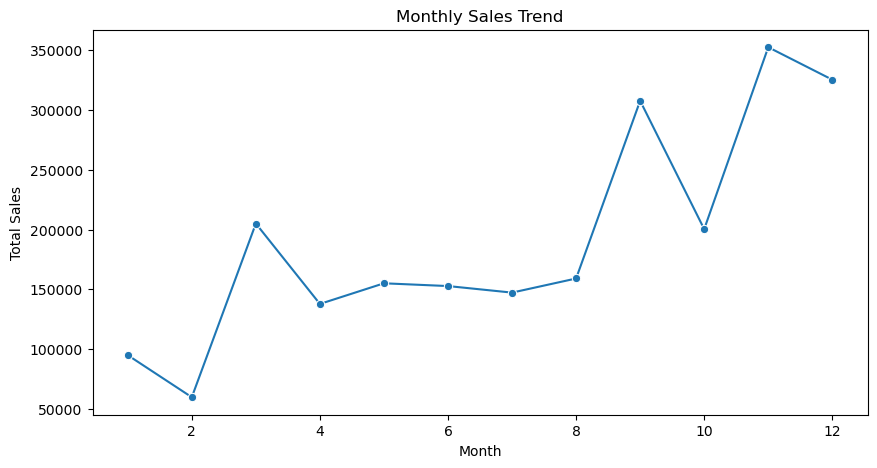

In [52]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

# Final Insights

Key findings from the analysis:

Overall, the analysis shows that the West region is the strongest market for sales, and Technology products generate the highest profit. The Consumer segment is the main contributor to revenue, while heavy discounting appears to negatively affect profitability. Additionally, sales tend to increase toward the end of the year, indicating possible seasonal buying patterns.

# Business Recommendations

• Reduce excessive discounts on low-margin products.

• Focus marketing on high-performing regions.

• Promote high-profit categories such as Technology.

• Monitor orders with large discounts to avoid losses.